# Tarea 2

**Objetivo**: Entrenar y comparar tus primeros modelos de clasificación supervisada utilizando el dataset del Titanic. Aprenderás a diagnosticar el sobreajuste (overfitting) y a interpretar qué factores influyeron más en la supervivencia.

**Dataset**: Continuaremos usando el archivo train.csv (Titanic [Aquí](https://colab.research.google.com/drive/1ePNCS_vBUGVm6x4lzkEbOuvsmbvi_Bo5#scrollTo=hgIUFIHnR4pU)) que analizaste en la Tarea 1 pero ahora cargaremos también el dataset test.csv.

In [85]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Aprendizaje supervisado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [86]:
# Cargamos el dataset una vez más
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Preparación: Train vs Test (El estudio y el examen)

**Concepto Teórico:**
> Para evaluar si nuestro modelo "generaliza" (aprende patrones reales) y no solo memoriza, **nunca** debemos evaluarlo con los mismos datos con los que entrenó. Dividiremos los datos en:
> * **Training Set (80%):** El libro de estudio.
> * **Test Set (20%):** El examen final oculto.

**Instrucciones:**
1.  **Ingeniería básica:** Scikit-learn necesita números. Convierte la variable `Sex` a numérica (ej: `female=1`, `male=0`).
2.  **Selección:** Define `X` con las variables numéricas (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `Sex_encoded`) y define `y` con la etiqueta (`Survived`).
3.  **Split:** Usa `train_test_split` con `random_state=42` para cortar los datos.

In [87]:
df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [88]:
col_quitar = ['PassengerId', 'Name', 'Survived', 'Ticket', 'Cabin', 'Embarked', 'Sex']
X = df.drop(columns=col_quitar)
y = df['Survived']
X["Age"] = X["Age"].fillna(X["Age"].median())

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

Datos de entrenamiento: (712, 6)
Datos de prueba: (179, 6)


## 2. El Baseline (El modelo "tonto")

**Concepto Teórico:**
> Antes de usar algoritmos complejos, necesitamos una referencia mínima. Si un modelo matemático no supera a una predicción ingenua (como predecir siempre la clase mayoritaria), no está aprendiendo nada útil.

**Instrucciones:**
1.  Calcula cuál es la clase mayoritaria en el dataset (¿Murió o Sobrevivió la mayoría?).
2.  Calcula qué porcentaje de acierto (Accuracy) tendrías si predijeras **siempre** esa clase para todos los pasajeros. Este es tu umbral mínimo a batir.

In [90]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy = "most_frequent")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_base)

print("BASELINE (Clase mayoritaria)")
print(f"Accuracy del baseline: {accuracy:.3f}")

BASELINE (Clase mayoritaria)
Accuracy del baseline: 0.587


## 3. Entrenamiento de Modelos ($h(x)$)

**Concepto Teórico:**
> Vamos a buscar la función hipótesis óptima $\hat{h}$ probando dos enfoques matemáticos distintos:
> * **Regresión Logística:** Un modelo lineal que busca separar las clases con una frontera recta (o hiperplano).
> * **Árbol de Decisión:** Un modelo no lineal que divide los datos mediante preguntas secuenciales en los nodos.

**Instrucciones:**
1.  Instancia y entrena una **Regresión Logística** usando solamente los datos de `Train`.
2.  Instancia y entrena un **Árbol de Decisión** (sin poner límites de profundidad) usando solamente los datos de `Train`.
3.  Calcula y muestra el `accuracy_score` de ambos modelos, tanto en el set de **Train** como en el de **Test**.

In [91]:
#LogisticRegression, DecisionTreeClassifier -> importadas a usar
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred_class_ts = model_log.predict(X_test)
y_pred_class_tr = model_log.predict(X_train)

acc_tr = accuracy_score(y_train, y_pred_class_tr)
acc_ts = accuracy_score(y_test, y_pred_class_ts)
print("REGRESIÓN LOGÍSTICA CLASIFIFCACION")
print(f"Exactitud Train: {acc_tr*100:.2f}%")
print(f"Exactitud Test: {acc_ts*100:.2f}%")


REGRESIÓN LOGÍSTICA CLASIFIFCACION
Exactitud Train: 80.20%
Exactitud Test: 81.01%


In [92]:
#DecisionTreeClassifier
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_overfit.fit(X_train, y_train)
print(f"[Árbol Infinito] Acurracy en Train (Memorización): {accuracy_score(y_train, tree_overfit.predict(X_train)):.2f}")

[Árbol Infinito] Acurracy en Train (Memorización): 0.98


## 4. Diagnóstico de Overfitting (Memorizar vs. Aprender)

**Concepto Teórico:**
> **Overfitting (Sobreajuste):** Ocurre cuando el modelo saca un 10 en el examen de práctica (Train) pero suspende el examen real (Test). Ha memorizado el "ruido" de los datos en lugar del patrón. Los árboles de decisión son propensos a esto si no se les pone límites.

**Instrucciones:**
1.  Compara el accuracy del Árbol del paso anterior en **Train** vs **Test**. ¿Hay mucha diferencia? (Si Train es casi 100% y Test es bajo, tienes overfitting).
2.  **Regularización:** Entrena un **nuevo** Árbol de Decisión limitando su profundidad (ej. `max_depth=3`).
3.  Evalúa este nuevo árbol. ¿Ha disminuido la brecha entre Train y Test? (Buscamos que el modelo sea más estable ante datos nuevos).

In [93]:
# Árbol Complejo
print(f"[Árbol Infinito] Accuracy en Train: {accuracy_score(y_train, tree_overfit.predict(X_train)):.2f}")
print(f"[Árbol Infinito] Accuracy en Test : {accuracy_score(y_test, tree_overfit.predict(X_test)):.2f}")
print("Hay bastante diferencia (23% de brecha) por tanto consideramos que hay overfitting")

[Árbol Infinito] Accuracy en Train: 0.98
[Árbol Infinito] Accuracy en Test : 0.75
Hay bastante diferencia (23% de brecha) por tanto consideramos que hay overfitting


In [94]:
tree_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth.fit(X_train, y_train)

print(f"[Árbol Infinito] Accuracy en Train: {accuracy_score(y_train, tree_depth.predict(X_train)):.2f}")
print(f"[Árbol Infinito] Accuracy en Test : {accuracy_score(y_test, tree_depth.predict(X_test)):.2f}")
print("Se observa que la brecha es mucho menor, por tanto no hay overfitting")

[Árbol Infinito] Accuracy en Train: 0.83
[Árbol Infinito] Accuracy en Test : 0.80
Se observa que la brecha es mucho menor, por tanto no hay overfitting


## 5. Interpretación (White Box)

**Concepto Teórico:**
> No nos basta con que el modelo prediga, queremos saber **qué aprendió**.
> * En modelos lineales miramos los **coeficientes** ($\beta$).
> * En árboles miramos la **importancia de variables** (cuánto reducen la impureza/caos).

**Instrucciones:**
1.  **Para la Regresión Logística:** Muestra los coeficientes asociados a cada variable. ¿Qué variables tienen coeficientes positivos (aumentan la probabilidad de sobrevivir) y cuáles negativos?
2.  **Para el Árbol de Decisión:** Muestra la importancia de las variables o visualiza el árbol gráficamente. ¿Cuál es la variable más importante ubicada en la raíz del árbol?

In [95]:
#Regresion Logistica
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": model_log.coef_[0]
})
coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)
print(coeficientes)

      Variable  Coeficiente
5  Sex_encoded     2.610552
4         Fare     0.003434
1          Age    -0.031450
3        Parch    -0.125206
2        SibSp    -0.315760
0       Pclass    -0.928176


In [96]:
#Arbol de Decision
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_depth.feature_importances_
})
importancia = importancia.sort_values(by='Importancia', ascending=False)

print("--- VARIABLES CLAVE SEGÚN EL ÁRBOL ---")
print(importancia.head(5))

--- VARIABLES CLAVE SEGÚN EL ÁRBOL ---
      Variable  Importancia
5  Sex_encoded     0.605737
0       Pclass     0.209536
1          Age     0.075353
4         Fare     0.061240
2        SibSp     0.048135


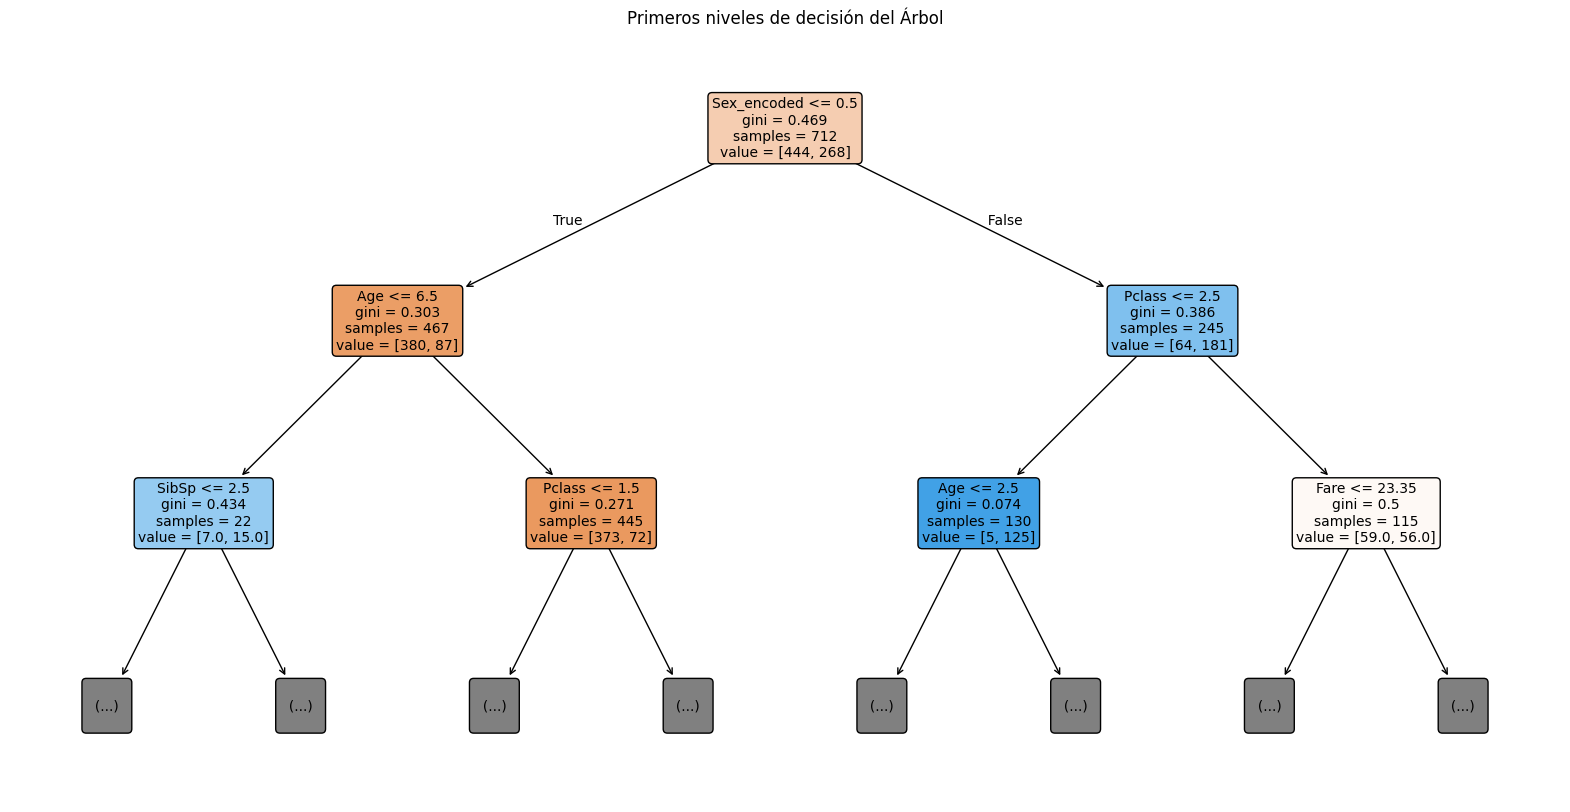

In [97]:
plt.figure(figsize=(20,10))
plot_tree(tree_depth, feature_names=list(X.columns), filled=True, rounded=True, max_depth=2, fontsize=10)
plt.title("Primeros niveles de decisión del Árbol")
plt.show()

## 6. Conclusiones

Escribe un breve resumen de texto respondiendo:
* ¿Qué modelo generalizó mejor en los datos de Test?
* ¿El árbol podado (regularizado) funcionó mejor que el ilimitado?
* Según tus modelos, ¿cuáles fueron los factores determinantes para sobrevivir en el Titanic?

- El modelo de Regresión Logistica generalizó mejor los datos con un accuracy del 81%, seguido del árbol regularizado con 80%
- El árbol podado (max_depth=3) funcionó notablemente mejor que el ilimitado, esto se debe a que memoriza menos.
- El factor más determinante fue el sexo.